In [1]:
## Load in the meshes - all ply files in /Users/tomkinsm/stomata-air-mattress/Meshes/PLY/
import os

def list_files_in_directory(directory):
    try:
        # List all files in the directory
        files = [f for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))]
        files = [f for f in files if f.endswith('.obj')]
        files = [f for f in files if f.startswith('mesh')]
        return files
    except Exception as e:
        print(f"An error occurred: {e}")
        return []

# Specify the directory
directory = '/Users/tomkinsm/stomata-air-mattress/Meshes/OBJ/'

# Get the list of files
meshes = list_files_in_directory(directory)

# Print the list of files
print("Files in directory:")
for file in meshes:
    print(file)

Files in directory:
mesh_1_8.obj
mesh_2_6b.obj
mesh_3_4.obj
mesh_1_6.obj
mesh_1_4.obj
mesh_2_6a.obj
mesh_3_6.obj
mesh_3_7.obj
mesh_1_5.obj
mesh_3_3.obj
mesh_2_7a.obj
mesh_3_2.obj
mesh_1_2.obj
mesh_3_1.obj
mesh_1_3.obj
mesh_2_4.obj
mesh_2_1.obj
mesh_2_3.obj


Widget(value='<iframe src="http://localhost:49304/index.html?ui=P_0x30a987920_0&reconnect=auto" class="pyvista…

Widget(value='<iframe src="http://localhost:49304/index.html?ui=P_0x30d0d9700_1&reconnect=auto" class="pyvista…

Widget(value='<iframe src="http://localhost:49304/index.html?ui=P_0x30a6aec00_2&reconnect=auto" class="pyvista…

Widget(value='<iframe src="http://localhost:49304/index.html?ui=P_0x30a804b90_3&reconnect=auto" class="pyvista…

Widget(value='<iframe src="http://localhost:49304/index.html?ui=P_0x30a839310_4&reconnect=auto" class="pyvista…

...

Widget(value='<iframe src="http://localhost:49304/index.html?ui=P_0x30aa11a90_13&reconnect=auto" class="pyvist…

Widget(value='<iframe src="http://localhost:49304/index.html?ui=P_0x30aa45df0_14&reconnect=auto" class="pyvist…

Widget(value='<iframe src="http://localhost:49304/index.html?ui=P_0x30aa71010_15&reconnect=auto" class="pyvist…

Widget(value='<iframe src="http://localhost:49304/index.html?ui=P_0x30aaa30b0_16&reconnect=auto" class="pyvist…

Widget(value='<iframe src="http://localhost:49304/index.html?ui=P_0x30aad3830_17&reconnect=auto" class="pyvist…

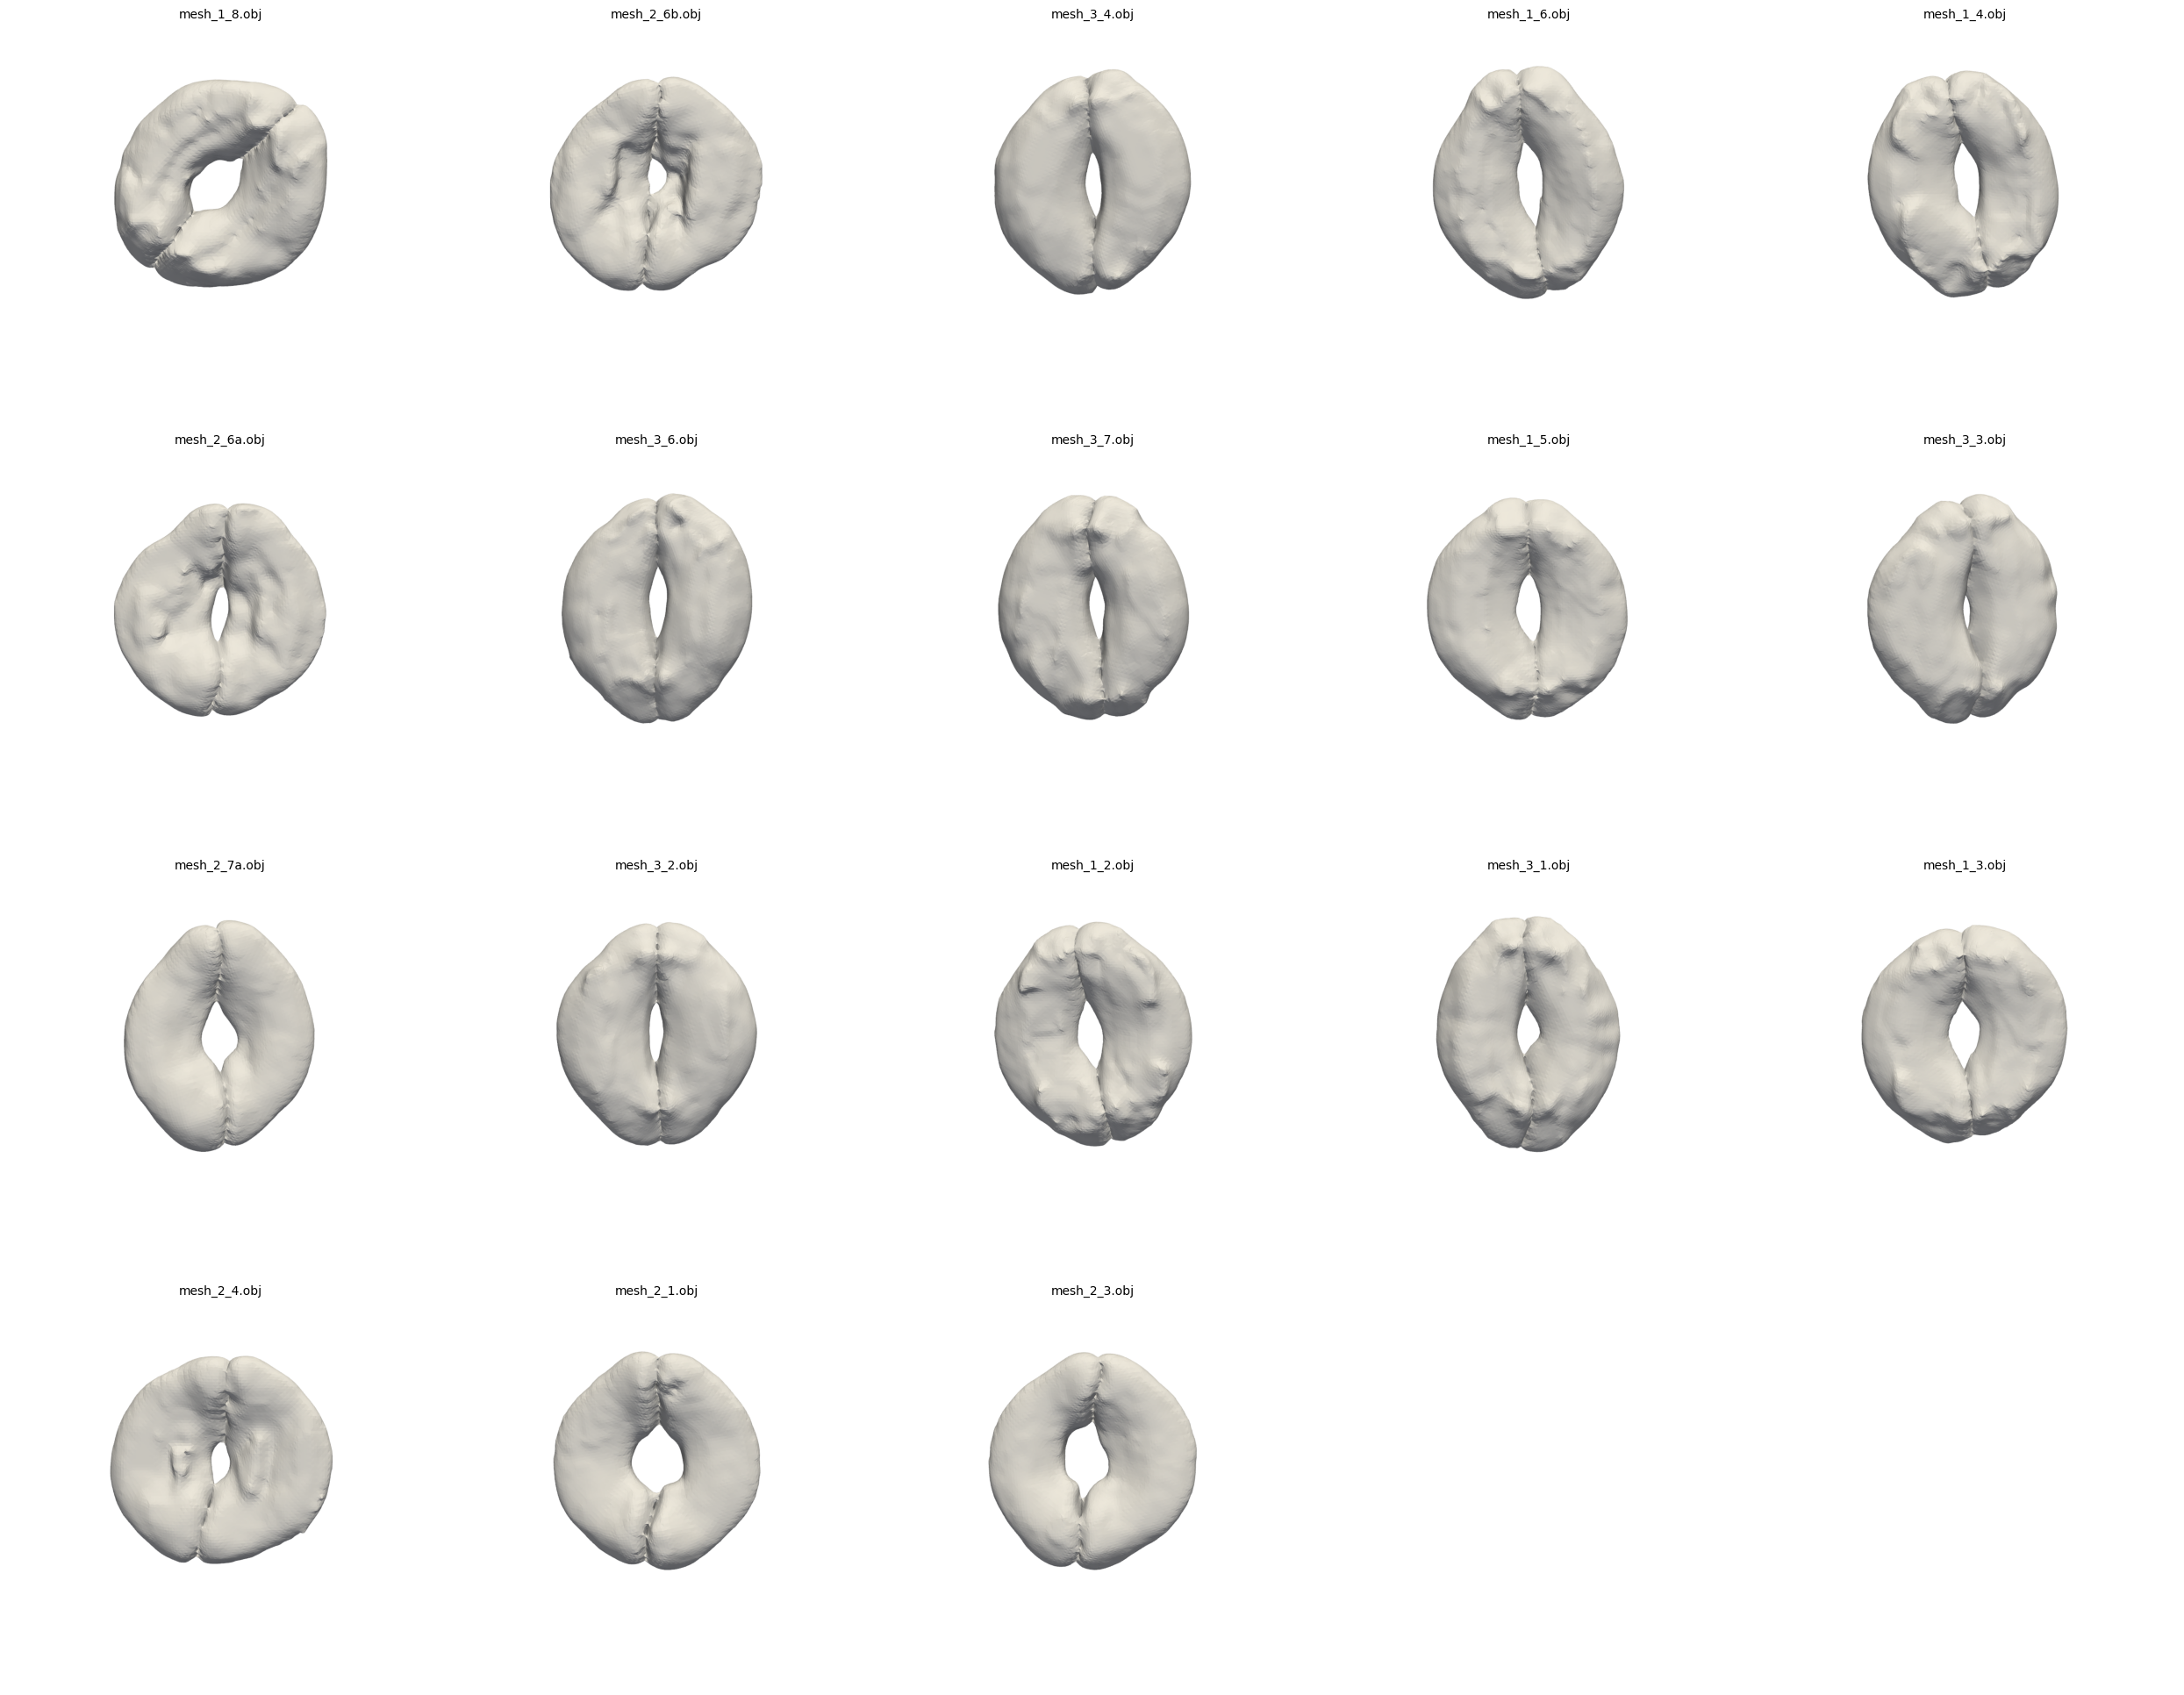

: 

In [ ]:
import pyvista as pv
import matplotlib.pyplot as plt
import numpy as np

import pyvista as pv
import matplotlib.pyplot as plt
import numpy as np

def render_obj_to_image(obj_file):
    # Load the OBJ file using pyvista
    mesh = pv.read(obj_file)
    
    # Create a plotter object
    plotter = pv.Plotter(off_screen=True)
    
    # Add the mesh to the plotter
    plotter.add_mesh(mesh, color='white')
    
    # Set a consistent camera position to view from the top
    plotter.view_xy()
    
    # Render the mesh to an image
    plotter.show(screenshot='temp_image.png')
    
    # Load the image
    image = plt.imread('temp_image.png')
    
    return image

def create_grid_of_images(obj_files, directory, grid_shape):
    # Create a figure with adjusted size
    fig, axes = plt.subplots(grid_shape[0], grid_shape[1], figsize=(grid_shape[1] * 5, grid_shape[0] * 5))
    
    # Flatten the axes array for easy iteration
    axes = axes.flatten()
    
    for ax, obj_file in zip(axes, obj_files):
        # Render the OBJ file to an image
        image = render_obj_to_image(directory + obj_file)
        
        # Display the image on the axis
        ax.imshow(image)
        ax.axis('off')

        # Set the title to the mesh name (file name)
        ax.set_title(obj_file, fontsize=10)
    
    # Hide any remaining empty subplots
    for ax in axes[len(obj_files):]:
        ax.axis('off')
    
    # Adjust the spacing between subplots
    plt.subplots_adjust(wspace=0.1, hspace=0.1)
    
    plt.tight_layout()
    plt.show()
# Example usage
grid_shape = (4, 5)  # Grid shape (rows, columns)
create_grid_of_images(meshes, directory, grid_shape)

In [15]:
## Start from the beginning
import pymeshlab as ml
import pyvista as pv
import numpy as np
from sklearn.neighbors import NearestNeighbors

def icp(A, B, max_iterations=100, tolerance=1e-6):
    """Perform Iterative Closest Point (ICP) algorithm to align points A to points B."""
    A = np.array(A)
    B = np.array(B)
    n_points, n_dims = A.shape

    # Initialize transformation
    R_mat = np.eye(n_dims)
    t = np.zeros(n_dims)
    A_aligned = A.copy()

    for _ in range(max_iterations):
        # Find the nearest neighbors
        distances = np.linalg.norm(A_aligned[:, np.newaxis] - B, axis=2)
        indices = np.argmin(distances, axis=1)
        B_matched = B[indices]

        # Compute centroids
        centroid_A = np.mean(A_aligned, axis=0)
        centroid_B = np.mean(B_matched, axis=0)

        # Center the points
        A_centered = A_aligned - centroid_A
        B_centered = B_matched - centroid_B

        # Compute covariance matrix and perform SVD
        H = A_centered.T @ B_centered
        U, _, Vt = np.linalg.svd(H)
        R_new = Vt.T @ U.T

        # Ensure proper rotation (det(R) = 1)
        if np.linalg.det(R_new) < 0:
            Vt[-1, :] *= -1
            R_new = Vt.T @ U.T

        t_new = centroid_B - R_new @ centroid_A

        # Apply transformation
        A_aligned = (R_new @ A_aligned.T).T + t_new

        # Check for convergence
        if np.linalg.norm(R_new - R_mat) < tolerance and np.linalg.norm(t_new - t) < tolerance:
            break

        R_mat = R_new
        t = t_new

    return A_aligned, R_mat, t

## Load in and simplfy the meshes, so that they have the same number of vertices / faces

def loadandcleanmesh(mesh_name):
    mesh = pv.read(mesh_name)
    clean_mesh = mesh.extract_geometry()
    return clean_mesh

def reduceVertices(mesh, target_faces, target_vertices,smooth_steps, outputname):
    ms = ml.MeshSet()
    ms.load_new_mesh(mesh)
    ms.apply_filter('apply_coord_laplacian_smoothing', stepsmoothnum=smooth_steps, boundary=False)
    m = ms.current_mesh()
    ms.apply_filter('meshing_decimation_quadric_edge_collapse', targetfacenum=target_faces, preserveboundary=True, preservenormal=True)
    m = ms.current_mesh()

    while m.vertex_number() != target_vertices:
        if m.vertex_number() < target_vertices:
            target_faces += 1
        else:
            target_faces -= 1
        ## Reload the mesh to apply the new target faces
        ms.load_new_mesh(mesh)
        ms.apply_filter('meshing_decimation_quadric_edge_collapse', targetfacenum=target_faces, preserveboundary=True, preservenormal=True)
        m = ms.current_mesh()
        print('output mesh has', m.vertex_number(), 'vertex and', m.face_number(), 'faces')
        ms.save_current_mesh(outputname)
    return m

def reduceAlignandAverage(directory, refMesh, meshtoalign, smooth_steps, output_name):
    ## Use the reference mesh to determine the number of vertices
    #mesh1 = loadandcleanmesh(directory + refMesh)
    #mesh1.save("cleaned_mesh_ref.ply")
    ms = ml.MeshSet()
    ms.load_new_mesh(directory + refMesh)
    ms.apply_filter('apply_coord_laplacian_smoothing', stepsmoothnum=smooth_steps, boundary=False)
    m = ms.current_mesh()
    print('Reference mesh has', m.vertex_number(), 'vertex and', m.face_number(), 'faces')
    ms.save_current_mesh('output_ref.obj')
    ref_target_faces = m.face_number()

    ## Load in the mesh to align
    #mesh2 = loadandcleanmesh(directory + meshtoalign)
    #mesh2.save("cleaned_mesh_to_align.ply")
    ## Need to set the target faces to some number less than either the reference or the mesh to align
    ms = ml.MeshSet()
    ms.load_new_mesh(directory + meshtoalign)
    m = ms.current_mesh()
    align_target_faces = m.face_number()

    target_faces = min(ref_target_faces, align_target_faces) - 100

    ## Reduce the reference mesh to get the target number of vertices
    ms = ml.MeshSet()
    ms.load_new_mesh('output_ref.obj')
    ms.apply_filter('meshing_decimation_quadric_edge_collapse', targetfacenum=target_faces, preserveboundary=True, preservenormal=True)
    m = ms.current_mesh()
    target_vertices = m.vertex_number()
    target_faces = m.face_number()
   
    reduceVertices(directory + meshtoalign, target_faces, target_vertices, 10, 'output_to_align.obj')

    ## Visualise the meshes
    #mesh1 = pv.read('output_ref.obj')
    #mesh2 = pv.read('output_to_align.obj')

    # Plot the meshes
    #p = pv.Plotter()
    #p.add_mesh(mesh1, color='red', show_edges=True)
    #p.add_mesh(mesh2, color='blue', show_edges=True)
    #p.show()

    ## Align the meshes
    mesh1 = pv.read('output_ref.obj')
    mesh2 = pv.read('output_to_align.obj')

    # Extract vertices from the meshes
    vertices1 = mesh1.points  # Reference vertices
    vertices2 = mesh2.points  # Vertices to align

    # Run ICP to align the misaligned mesh to the reference mesh
    aligned_vertices, R_icp, t_icp = icp(vertices2, vertices1)

    # Create new meshes for visualization
    aligned_mesh = pv.PolyData(aligned_vertices, mesh2.faces)  # Aligned mesh
    misaligned_mesh = pv.PolyData(vertices2, mesh2.faces)  # Misaligned mesh

    # Visualization
    #plotter = pv.Plotter()
    #plotter.add_mesh(mesh1, color="blue", opacity=0.3, label="Reference Mesh", style="wireframe")
    #plotter.add_mesh(misaligned_mesh, color="green", opacity=1.0, label="Misaligned Mesh", style="wireframe")
    #plotter.add_mesh(aligned_mesh, color="red", opacity=1.0, label="Aligned Mesh", style="wireframe")
    #plotter.add_legend()
    #plotter.show()

    # Optionally, save the aligned mesh as a new PLY file
    aligned_mesh.save("aligned_mesh.obj")

    ## Find the average mesh between mesh1, aligned_mesh

    # Extract vertices from the meshes
    vertices1 = mesh1.points  # Reference vertices
    vertices2 = aligned_mesh.points  # Vertices to align

    # Use NearestNeighbors to find the closest points in mesh1 for each point in mesh2
    nn = NearestNeighbors(n_neighbors=1, algorithm='auto')
    nn.fit(vertices1)
    distances, indices = nn.kneighbors(vertices2)

    # Calculate the average coordinates between corresponding vertices
    average_vertices = (vertices1[indices.flatten()] + vertices2) / 2
    average_mesh = pv.PolyData(average_vertices, aligned_mesh.faces)

    # Visualization
    #plotter = pv.Plotter()
    #plotter.add_mesh(mesh1, color="blue", opacity=0.3, label="Reference Mesh", style="wireframe")
    #plotter.add_mesh(aligned_mesh, color="red", opacity=1.0, label="Aligned Mesh", style="wireframe")
    #plotter.add_mesh(average_mesh, color="green", opacity=1.0, label="Average Mesh", style="wireframe")
    #plotter.add_legend()
    #plotter.show()

    ## Save the average mesh
    average_mesh.save(directory + output_name)
    



In [16]:
import random

def create_random_pairs(input_list):
    # Shuffle the list to randomize the order of elements
    random.shuffle(input_list)
    
    # Create pairs from the shuffled list
    pairs = []
    for i in range(0, len(input_list) - 1, 2):
        pairs.append((input_list[i], input_list[i + 1]))
    
    # If the list has an odd number of elements, the last element will be left out
    if len(input_list) % 2 != 0:
        print(f"Warning: The list has an odd number of elements. The last element '{input_list[-1]}' is left out.")
    
    return pairs


In [17]:
## Select pairs of meshes from the list of meshes
random_pairs = create_random_pairs(meshes)
print(random_pairs)

## Create output list
averaged_meshes = []

while len(averaged_meshes) != 1:
    for pair in random_pairs:
        refMesh = pair[0]
        meshtoalign = pair[1]
        output_name = 'average_' + refMesh + '_' + meshtoalign
        reduceAlignandAverage(directory, refMesh, meshtoalign, 10, output_name)
        averaged_meshes.append(output_name)
    if len(averaged_meshes) != 1:
        random_pairs = create_random_pairs(averaged_meshes)
        averaged_meshes = []

[('mesh_2_6a.obj', 'mesh_3_7.obj'), ('mesh_1_3.obj', 'mesh_3_6.obj'), ('mesh_3_2.obj', 'mesh_2_6b.obj'), ('mesh_3_3.obj', 'mesh_2_1.obj'), ('mesh_3_4.obj', 'mesh_1_6.obj'), ('mesh_1_4.obj', 'mesh_1_2.obj'), ('mesh_3_1.obj', 'mesh_2_3.obj'), ('mesh_1_8.obj', 'mesh_2_7a.obj'), ('mesh_2_4.obj', 'mesh_1_5.obj')]
Reference mesh has 12911 vertex and 26001 faces
output mesh has 12871 vertex and 25900 faces
output mesh has 12870 vertex and 25898 faces
output mesh has 12870 vertex and 25898 faces
output mesh has 12869 vertex and 25896 faces
output mesh has 12869 vertex and 25896 faces
output mesh has 12868 vertex and 25894 faces
output mesh has 12868 vertex and 25894 faces
output mesh has 12867 vertex and 25892 faces
output mesh has 12867 vertex and 25892 faces
output mesh has 12866 vertex and 25890 faces
output mesh has 12866 vertex and 25890 faces
output mesh has 12865 vertex and 25888 faces
output mesh has 12865 vertex and 25888 faces
output mesh has 12864 vertex and 25886 faces
output mesh 

ERROR:root:Unable to open file: /Users/tomkinsm/stomata-air-mattress/Meshes/OBJ/average_average_average_average_mesh_2_4.obj_mesh_1_5.obj_average_mesh_1_4.obj_mesh_1_2.obj_average_average_mesh_2_6a.obj_mesh_3_7.obj_average_mesh_3_2.obj_mesh_2_6b.obj_average_average_average_mesh_3_1.obj_mesh_2_3.obj_average_mesh_3_4.obj_mesh_1_6.obj_average_average_mesh_1_3.obj_mesh_3_6.obj_average_mesh_1_8.obj_mesh_2_7a.obj
2025-02-04 12:38:17.921 (5327.145s) [         167923E]       vtkOBJWriter.cxx:244    ERR| vtkOBJWriter (0x3c0404310): Unable to open file: /Users/tomkinsm/stomata-air-mattress/Meshes/OBJ/average_average_average_average_mesh_2_4.obj_mesh_1_5.obj_average_mesh_1_4.obj_mesh_1_2.obj_average_average_mesh_2_6a.obj_mesh_3_7.obj_average_mesh_3_2.obj_mesh_2_6b.obj_average_average_average_mesh_3_1.obj_mesh_2_3.obj_average_mesh_3_4.obj_mesh_1_6.obj_average_average_mesh_1_3.obj_mesh_3_6.obj_average_mesh_1_8.obj_mesh_2_7a.obj


In [19]:
averaged_meshes[0]

'average_average_average_average_mesh_2_4.obj_mesh_1_5.obj_average_mesh_1_4.obj_mesh_1_2.obj_average_average_mesh_2_6a.obj_mesh_3_7.obj_average_mesh_3_2.obj_mesh_2_6b.obj_average_average_average_mesh_3_1.obj_mesh_2_3.obj_average_mesh_3_4.obj_mesh_1_6.obj_average_average_mesh_1_3.obj_mesh_3_6.obj_average_mesh_1_8.obj_mesh_2_7a.obj'

In [25]:
## Load in and visulathe the averaged mesh
mesh = pv.read(directory + "average_mesh_final.obj")
p = pv.Plotter()
p.add_mesh(mesh, color='red', show_edges=True)
p.show()

Widget(value='<iframe src="http://localhost:54049/index.html?ui=P_0x33368c560_56&reconnect=auto" class="pyvist…

In [ ]:




## Create the first average mesh
reduceAlignandAverage(directory, meshes[0], meshes[1], 10)

## Iterate over the remaining meshes, using the new average mesh as the reference
for i in range(2, len(meshes)):
    reduceAlignandAverage(directory, "average_mesh.obj", meshes[i], 10)

In [7]:
## Load in and visualise all of the meshes. Set the opacity of the original meshes to 25%, and the opacity of the average mesh to 100%
mesh1 = pv.read(directory + meshes[0])
mesh2 = pv.read(directory + meshes[1])
mesh3 = pv.read(directory + meshes[2])
mesh4 = pv.read(directory + meshes[3])
mesh5 = pv.read("average_mesh.ply")

# Plot the meshes
p = pv.Plotter()
#p.add_mesh(mesh1, color='red', show_edges=True, opacity=0.25)
#p.add_mesh(mesh2, color='blue', show_edges=True, opacity=0.25)
#p.add_mesh(mesh3, color='green', show_edges=True, opacity=0.25)
#p.add_mesh(mesh4, color='yellow', show_edges=True, opacity=0.25)
p.add_mesh(mesh5, color='black', style='wireframe')
p.show()


Widget(value='<iframe src="http://localhost:53292/index.html?ui=P_0x33aec00e0_12&reconnect=auto" class="pyvist…

In [10]:
import pyvista as pv
import pymeshlab as ml

# Load the mesh using pyvista
mesh = pv.read('average_mesh.ply')

# Save the mesh to a temporary file to load it into pymeshlab
mesh.save('temp_mesh.ply')

# Load the mesh using pymeshlab
ms = ml.MeshSet()
ms.load_new_mesh('temp_mesh.ply')

# Apply filters to clean and repair the mesh
ms.apply_filter('meshing_remove_duplicate_faces')
ms.apply_filter('meshing_remove_duplicate_vertices')
ms.apply_filter('meshing_remove_unreferenced_vertices')
ms.apply_filter('meshing_repair_non_manifold_edges')
ms.apply_filter('meshing_repair_non_manifold_vertices')
ms.apply_filter('meshing_close_holes', maxholesize=100)  # Adjust maxholesize as needed

# Save the cleaned mesh
ms.save_current_mesh('cleaned_mesh.ply')

# Load the cleaned mesh using pyvista to visualize it
cleaned_mesh = pv.read('cleaned_mesh.ply')

# Create a plotter object
plotter = pv.Plotter()

# Add the cleaned mesh to the plotter
plotter.add_mesh(cleaned_mesh, color='white', show_edges=True, edge_color='black')

# Show the plot
plotter.show()

Widget(value='<iframe src="http://localhost:53292/index.html?ui=P_0x33a99d5e0_13&reconnect=auto" class="pyvist…

In [12]:
import pyvista as pv

# Load the mesh using pyvista
mesh = pv.read('average_mesh.ply')

# Save the mesh to a temporary file to load it into pymeshlab
mesh.save('temp_mesh.ply')

# Load the mesh using pymeshlab
ms = ml.MeshSet()
ms.load_new_mesh('temp_mesh.ply')

# Apply filters to clean and repair the mesh
ms.apply_filter('meshing_remove_duplicate_faces')
ms.apply_filter('meshing_remove_duplicate_vertices')
ms.apply_filter('meshing_remove_unreferenced_vertices')
ms.apply_filter('meshing_repair_non_manifold_edges')
ms.apply_filter('meshing_repair_non_manifold_vertices')
ms.apply_filter('meshing_remove_null_faces')
ms.apply_filter('meshing_remove_folded_faces')
ms.apply_filter('meshing_close_holes', maxholesize=1000)  # Increase maxholesize as needed
ms.apply_filter('compute_normal_per_vertex')

# Save the cleaned mesh
ms.save_current_mesh('cleaned_mesh.ply')

# Load the cleaned mesh using pyvista to visualize it
cleaned_mesh = pv.read('cleaned_mesh.ply')

# Create a plotter object
plotter = pv.Plotter()

# Add the cleaned mesh to the plotter
plotter.add_mesh(cleaned_mesh, color='white', show_edges=True, edge_color='black')

# Show the plot
plotter.show()

Widget(value='<iframe src="http://localhost:53292/index.html?ui=P_0x369025430_15&reconnect=auto" class="pyvist…

In [ ]:


ref_mesh = directory + 'mesh_1_2.ply'
mesh1 = loadandcleanmesh(ref_mesh)
mesh1.save("cleaned_mesh1.ply")

## Use the reference mesh to determine the number of vertices
target_faces = 20000
smooth_steps = 10
ms = ml.MeshSet()
ms.load_new_mesh('cleaned_mesh1.ply')
ms.apply_filter('apply_coord_laplacian_smoothing', stepsmoothnum=smooth_steps, boundary=False)
ms.apply_filter('meshing_decimation_quadric_edge_collapse', targetfacenum=target_faces, preserveboundary=True, preservenormal=True)
m = ms.current_mesh()
print('output mesh has', m.vertex_number(), 'vertex and', m.face_number(), 'faces')
ms.save_current_mesh('output1.ply')

target_vertices = m.vertex_number()


In [17]:
## Repeat for all meshes in the directory
## Clean the mesh
clean_mesh = loadandcleanmesh(directory + meshes[1])
clean_mesh.save("cleaned_mesh2.ply")

## Reduce the mesh
reduced_mesh = reduceVertices('cleaned_mesh2.ply', target_faces, target_vertices, "output2.ply")


output mesh has 9923 vertex and 20000 faces
output mesh has 9924 vertex and 20002 faces
output mesh has 9924 vertex and 20002 faces
output mesh has 9925 vertex and 20004 faces
output mesh has 9925 vertex and 20004 faces
output mesh has 9926 vertex and 20006 faces


In [18]:
## Visualise the meshes
# Load the cleaned meshes
mesh1 = pv.read('output1.ply')
mesh2 = pv.read('output2.ply')

# Plot the meshes
p = pv.Plotter()
p.add_mesh(mesh1, color='red', show_edges=True)
p.add_mesh(mesh2, color='blue', show_edges=True)
p.show()

Widget(value='<iframe src="http://localhost:62208/index.html?ui=P_0x312779430_3&reconnect=auto" class="pyvista…

In [19]:
## Align the meshes

import pyvista as pv
import numpy as np
from scipy.spatial.transform import Rotation as R

def icp(A, B, max_iterations=100, tolerance=1e-6):
    """Perform Iterative Closest Point (ICP) algorithm to align points A to points B."""
    A = np.array(A)
    B = np.array(B)
    n_points, n_dims = A.shape

    # Initialize transformation
    R_mat = np.eye(n_dims)
    t = np.zeros(n_dims)
    A_aligned = A.copy()

    for _ in range(max_iterations):
        # Find the nearest neighbors
        distances = np.linalg.norm(A_aligned[:, np.newaxis] - B, axis=2)
        indices = np.argmin(distances, axis=1)
        B_matched = B[indices]

        # Compute centroids
        centroid_A = np.mean(A_aligned, axis=0)
        centroid_B = np.mean(B_matched, axis=0)

        # Center the points
        A_centered = A_aligned - centroid_A
        B_centered = B_matched - centroid_B

        # Compute covariance matrix and perform SVD
        H = A_centered.T @ B_centered
        U, _, Vt = np.linalg.svd(H)
        R_new = Vt.T @ U.T

        # Ensure proper rotation (det(R) = 1)
        if np.linalg.det(R_new) < 0:
            Vt[-1, :] *= -1
            R_new = Vt.T @ U.T

        t_new = centroid_B - R_new @ centroid_A

        # Apply transformation
        A_aligned = (R_new @ A_aligned.T).T + t_new

        # Check for convergence
        if np.linalg.norm(R_new - R_mat) < tolerance and np.linalg.norm(t_new - t) < tolerance:
            break

        R_mat = R_new
        t = t_new

    return A_aligned, R_mat, t

# Load PLY meshes
mesh1 = pv.read("output1.ply")  # Reference mesh
mesh2 = pv.read("output2.ply")  # Mesh to align

# Extract vertices from the meshes
vertices1 = mesh1.points  # Reference vertices
vertices2 = mesh2.points  # Vertices to align

# Run ICP to align the misaligned mesh to the reference mesh
aligned_vertices, R_icp, t_icp = icp(vertices2, vertices1)

# Create new meshes for visualization
aligned_mesh = pv.PolyData(aligned_vertices, mesh2.faces)  # Aligned mesh
misaligned_mesh = pv.PolyData(vertices2, mesh2.faces)  # Misaligned mesh

# Visualization
plotter = pv.Plotter()
plotter.add_mesh(mesh1, color="blue", opacity=0.3, label="Reference Mesh", style="wireframe")
plotter.add_mesh(misaligned_mesh, color="green", opacity=1.0, label="Misaligned Mesh", style="wireframe")
plotter.add_mesh(aligned_mesh, color="red", opacity=1.0, label="Aligned Mesh", style="wireframe")
plotter.add_legend()
plotter.show()

# Optionally, save the aligned mesh as a new PLY file
aligned_mesh.save("aligned_mesh.ply")


Widget(value='<iframe src="http://localhost:62208/index.html?ui=P_0x33da6ac60_4&reconnect=auto" class="pyvista…

In [14]:
## Load the aligned mesh
aligned_mesh = pv.read('aligned_mesh.ply')
mesh1 = pv.read('output1.ply')

# Visualization
plotter = pv.Plotter()
plotter.add_mesh(mesh1, color="blue", opacity=0.3, label="Reference Mesh", style="wireframe")
plotter.add_mesh(aligned_mesh, color="red", opacity=1.0, label="Aligned Mesh", style="wireframe")
plotter.add_legend()
plotter.show()



Widget(value='<iframe src="http://localhost:62208/index.html?ui=P_0x312779280_2&reconnect=auto" class="pyvista…

In [15]:
## Find the average mesh between mesh1, aligned_mesh
# Compute the average mesh
from sklearn.neighbors import NearestNeighbors

# Extract vertices from the meshes
vertices1 = mesh1.points  # Reference vertices
vertices2 = aligned_mesh.points  # Vertices to align

# Use NearestNeighbors to find the closest points in mesh1 for each point in mesh2
nn = NearestNeighbors(n_neighbors=1, algorithm='auto')
nn.fit(vertices1)
distances, indices = nn.kneighbors(vertices2)

# Calculate the average coordinates between corresponding vertices
average_vertices = (vertices1[indices.flatten()] + vertices2) / 2
average_mesh = pv.PolyData(average_vertices, aligned_mesh.faces)

# Visualization
plotter = pv.Plotter()
#plotter.add_mesh(mesh1, color="blue", opacity=0.3, label="Reference Mesh", style="wireframe")
#plotter.add_mesh(aligned_mesh, color="red", opacity=1.0, label="Aligned Mesh", style="wireframe")
plotter.add_mesh(average_mesh, color="green", opacity=1.0, label="Average Mesh", style="wireframe")
plotter.add_legend()
plotter.show()


Widget(value='<iframe src="http://localhost:54116/index.html?ui=P_0x358b66d80_11&reconnect=auto" class="pyvist…

In [27]:
import pyvista as pv
import numpy as np
from scipy.spatial.transform import Rotation as R

def icp(A, B, max_iterations=100, tolerance=1e-6):
    """Perform Iterative Closest Point (ICP) algorithm to align points A to points B."""
    A = np.array(A)
    B = np.array(B)
    n_points, n_dims = A.shape

    # Initialize transformation
    R_mat = np.eye(n_dims)
    t = np.zeros(n_dims)
    A_aligned = A.copy()

    for _ in range(max_iterations):
        # Find the nearest neighbors
        distances = np.linalg.norm(A_aligned[:, np.newaxis] - B, axis=2)
        indices = np.argmin(distances, axis=1)
        B_matched = B[indices]

        # Compute centroids
        centroid_A = np.mean(A_aligned, axis=0)
        centroid_B = np.mean(B_matched, axis=0)

        # Center the points
        A_centered = A_aligned - centroid_A
        B_centered = B_matched - centroid_B

        # Compute covariance matrix and perform SVD
        H = A_centered.T @ B_centered
        U, _, Vt = np.linalg.svd(H)
        R_new = Vt.T @ U.T

        # Ensure proper rotation (det(R) = 1)
        if np.linalg.det(R_new) < 0:
            Vt[-1, :] *= -1
            R_new = Vt.T @ U.T

        t_new = centroid_B - R_new @ centroid_A

        # Apply transformation
        A_aligned = (R_new @ A_aligned.T).T + t_new

        # Check for convergence
        if np.linalg.norm(R_new - R_mat) < tolerance and np.linalg.norm(t_new - t) < tolerance:
            break

        R_mat = R_new
        t = t_new

    return A_aligned, R_mat, t

# Create the reference torus (Larger Torus)
torus1 = pv.ParametricTorus()
vertices1 = torus1.points.copy()  # Ensure reference points remain unchanged

# Create the second torus (Smaller Torus)
torus2 = pv.ParametricTorus()
vertices2 = torus2.points.copy()

# Apply an initial misalignment: Rotation + Translation
rotation = R.from_euler('y', 30, degrees=True).as_matrix()  # Rotate 30° around Z-axis
translation = np.array([0.5, 0.5, 0])  # Shift along X and Y axes
transformed_vertices = (rotation @ vertices2.T).T + translation  # Apply rotation + translation

# Run ICP to align the misaligned torus with the reference torus
aligned_vertices, R_icp, t_icp = icp(transformed_vertices, vertices1)

# Create PolyData objects for visualization
reference_torus = pv.PolyData(vertices1, torus1.faces)  # Reference (blue)
misaligned_torus = pv.PolyData(transformed_vertices, torus2.faces)  # Misaligned (green)
aligned_torus = pv.PolyData(aligned_vertices, torus2.faces)  # Aligned (red)

# Visualization
plotter = pv.Plotter()
plotter.add_mesh(reference_torus, color="blue", opacity=0.3, label="Reference Torus", style="wireframe")
plotter.add_mesh(misaligned_torus, color="green", opacity=1.0, label="Misaligned Torus", style="wireframe")
plotter.add_mesh(aligned_torus, color="red", opacity=1.0, label="Aligned Torus", style="wireframe")
plotter.add_legend()
plotter.show()

INFO: trigger(trigger__99)
INFO: trigger(trigger__100)
INFO: trigger(P_0x365e0cb00_14Camera)
INFO: trigger(P_0x365e0cb00_14AnimateStart)
INFO: trigger(P_0x365e0cb00_14AnimateStop)
INFO: js_key = class
INFO: js_key = style
INFO: js_key = fluid
INFO: js_key = class
INFO: before: class = { 'rounded-circle': !P_0x365e0cb00_14_show_ui }
INFO: (prefix=None) token {
INFO: has({ => {) = False
INFO: (prefix=None) token  
INFO: has(  =>  ) = False
INFO: (prefix=None) token '
INFO: has(' => ') = False
INFO: (prefix=None) token rounded
INFO: has(rounded => rounded) = False
INFO: (prefix=None) token -
INFO: has(- => -) = False
INFO: (prefix=None) token circle
INFO: has(circle => circle) = False
INFO: (prefix=None) token '
INFO: has(' => ') = False
INFO: (prefix=None) token :
INFO: has(: => :) = False
INFO: (prefix=None) token  
INFO: has(  =>  ) = False
INFO: (prefix=None) token !
INFO: has(! => !) = False
INFO: (prefix=None) token P_0x365e0cb00_14_show_ui
INFO: has(P_0x365e0cb00_14_show_ui => P_0x

Widget(value='<iframe src="http://localhost:54525/index.html?ui=P_0x365e0cb00_14&reconnect=auto" class="pyvist…

In [3]:
## Apply the above function to PLY meshes of the stomata

import pyvista as pv
import numpy as np
from scipy.spatial.transform import Rotation as R

def icp(A, B, max_iterations=100, tolerance=1e-6):
    """Perform Iterative Closest Point (ICP) algorithm to align points A to points B."""
    A = np.array(A)
    B = np.array(B)
    n_points, n_dims = A.shape

    # Initialize transformation
    R_mat = np.eye(n_dims)
    t = np.zeros(n_dims)
    A_aligned = A.copy()

    for _ in range(max_iterations):
        # Find the nearest neighbors
        distances = np.linalg.norm(A_aligned[:, np.newaxis] - B, axis=2)
        indices = np.argmin(distances, axis=1)
        B_matched = B[indices]

        # Compute centroids
        centroid_A = np.mean(A_aligned, axis=0)
        centroid_B = np.mean(B_matched, axis=0)

        # Center the points
        A_centered = A_aligned - centroid_A
        B_centered = B_matched - centroid_B

        # Compute covariance matrix and perform SVD
        H = A_centered.T @ B_centered
        U, _, Vt = np.linalg.svd(H)
        R_new = Vt.T @ U.T

        # Ensure proper rotation (det(R) = 1)
        if np.linalg.det(R_new) < 0:
            Vt[-1, :] *= -1
            R_new = Vt.T @ U.T

        t_new = centroid_B - R_new @ centroid_A

        # Apply transformation
        A_aligned = (R_new @ A_aligned.T).T + t_new

        # Check for convergence
        if np.linalg.norm(R_new - R_mat) < tolerance and np.linalg.norm(t_new - t) < tolerance:
            break

        R_mat = R_new
        t = t_new

    return A_aligned, R_mat, t

# Load PLY meshes
mesh1 = pv.read("/Users/tomkinsm/stomata-air-mattress/Meshes/PLY/mesh_1_2.ply")  # Reference mesh
mesh2 = pv.read("/Users/tomkinsm/stomata-air-mattress/Meshes/PLY/mesh_1_3.ply")  # Mesh to align

# Extract vertices from the meshes
vertices1 = mesh1.points  # Reference vertices
vertices2 = mesh2.points  # Vertices to align

# Run ICP to align the misaligned mesh to the reference mesh
aligned_vertices, R_icp, t_icp = icp(vertices2, vertices1)

# Create new meshes for visualization
aligned_mesh = pv.PolyData(aligned_vertices, mesh2.faces)  # Aligned mesh
misaligned_mesh = pv.PolyData(vertices2, mesh2.faces)  # Misaligned mesh

# Visualization
plotter = pv.Plotter()
plotter.add_mesh(mesh1, color="blue", opacity=0.3, label="Reference Mesh", style="wireframe")
plotter.add_mesh(misaligned_mesh, color="green", opacity=1.0, label="Misaligned Mesh", style="wireframe")
plotter.add_mesh(aligned_mesh, color="red", opacity=1.0, label="Aligned Mesh", style="wireframe")
plotter.add_legend()
plotter.show()

# Optionally, save the aligned mesh as a new PLY file
aligned_mesh.save("aligned_mesh.ply")

Widget(value='<iframe src="http://localhost:64074/index.html?ui=P_0x320eb9460_1&reconnect=auto" class="pyvista…

In [4]:
## Code to align multiple meshes

import pyvista as pv
import numpy as np
import glob
from scipy.spatial.transform import Rotation as R

def icp(A, B, max_iterations=100, tolerance=1e-6):
    """Perform Iterative Closest Point (ICP) algorithm to align points A to points B."""
    A = np.array(A)
    B = np.array(B)
    n_points, n_dims = A.shape

    # Initialize transformation
    R_mat = np.eye(n_dims)
    t = np.zeros(n_dims)
    A_aligned = A.copy()

    for _ in range(max_iterations):
        # Find the nearest neighbors
        distances = np.linalg.norm(A_aligned[:, np.newaxis] - B, axis=2)
        indices = np.argmin(distances, axis=1)
        B_matched = B[indices]

        # Compute centroids
        centroid_A = np.mean(A_aligned, axis=0)
        centroid_B = np.mean(B_matched, axis=0)

        # Center the points
        A_centered = A_aligned - centroid_A
        B_centered = B_matched - centroid_B

        # Compute covariance matrix and perform SVD
        H = A_centered.T @ B_centered
        U, _, Vt = np.linalg.svd(H)
        R_new = Vt.T @ U.T

        # Ensure proper rotation (det(R) = 1)
        if np.linalg.det(R_new) < 0:
            Vt[-1, :] *= -1
            R_new = Vt.T @ U.T

        t_new = centroid_B - R_new @ centroid_A

        # Apply transformation
        A_aligned = (R_new @ A_aligned.T).T + t_new

        # Check for convergence
        if np.linalg.norm(R_new - R_mat) < tolerance and np.linalg.norm(t_new - t) < tolerance:
            break

        R_mat = R_new
        t = t_new

    return A_aligned, R_mat, t

def resample_mesh(mesh, num_points=5000):
    """Clean, repair, and resample the mesh to a fixed number of points."""

    mesh = mesh.clean()

    if not mesh.is_all_triangles:
        mesh = mesh.triangulate()

    if not mesh.is_manifold:
        print("Skipping subdivision: mesh is non-manifold.")
        return mesh.points[:num_points]

    # REMOVE subdivision and decimation to avoid crashes
    return mesh.points[:num_points]


def load_and_align_meshes(ply_files, num_points=5000):
    """Load, resample, and align multiple PLY meshes to the first mesh as reference."""
    meshes = [pv.read(f) for f in ply_files]  # Load all PLY meshes
    resampled_meshes = [resample_mesh(mesh, num_points) for mesh in meshes]  # Resample meshes

    reference_vertices = resampled_meshes[0]  # Use the first mesh as the reference
    aligned_meshes = [reference_vertices]  # Store the reference mesh as already aligned

    for vertices in resampled_meshes[1:]:
        aligned_vertices, _, _ = icp(vertices, reference_vertices)  # Align to reference
        aligned_meshes.append(aligned_vertices)

    return np.array(aligned_meshes), meshes[0]  # Use first mesh for faces


# Get all PLY files
ply_files = glob.glob("/Users/tomkinsm/stomata-air-mattress/Meshes/PLY/*.ply")

# Align all meshes
aligned_meshes, ref_mesh = load_and_align_meshes(ply_files)

# Compute the mean shape by averaging vertex positions
mean_vertices = np.mean(aligned_meshes, axis=0)

# Create a new mesh using the averaged vertices
#mean_mesh = pv.PolyData(mean_vertices, ref_mesh.faces)
print(ref_mesh.faces.shape)
# Assuming ref_mesh.faces is a 1D array with the correct number of elements
faces = ref_mesh.faces.reshape(-1, 4)[:, 1:]  # Reshape and remove the number of vertices per face
mean_mesh = pv.PolyData(mean_vertices, faces)
mean_mesh.plot()



# Save the generalized mesh
#mean_mesh.save("generalized_mesh.ply")



Skipping subdivision: mesh is non-manifold.
Skipping subdivision: mesh is non-manifold.
(110864,)


CellSizeError: `faces` cell array size is invalid.

In [5]:
# Check the number of vertices and faces in the mesh
num_faces = len(ref_mesh.faces) // 4
print(f"Number of faces: {num_faces}")

# Check the shape of mean_vertices
print(f"Shape of mean_vertices: {mean_vertices.shape}")



Number of faces: 27716
Shape of mean_vertices: (5000, 3)


In [10]:
## Need to focus on the function to resample a mesh

import pymeshlab as ml

# Load the mesh
ms = ml.MeshSet()
ms.load_new_mesh('/Users/tomkinsm/stomata-air-mattress/Meshes/PLY/mesh_1_2.ply')

# Clean the mesh by removing invalid faces or vertices
ms.apply_filter('remove_isolated_vertices')
ms.apply_filter('remove_duplicate_faces')

m = ms.current_mesh()

# Output initial vertex and face count
print('Input mesh has', m.vertex_number(), 'vertices and', m.face_number(), 'faces')

# Target number of vertices
TARGET = 10000

# Estimate number of faces required using Euler's characteristic approximation
numFaces = 100 + 2 * TARGET  # Add a small buffer for initial decimation

# Simplify the mesh and converge towards the target vertex count
while ms.current_mesh().vertex_number() > TARGET:
    ms.apply_filter('simplification_quadric_edge_collapse_decimation', targetfacenum=numFaces, preservenormal=True)
    print(f"Decimated to {numFaces} faces. Mesh has {ms.current_mesh().vertex_number()} vertices.")
    
    # Refine the number of faces for the next iteration based on the vertex count
    numFaces = numFaces - (ms.current_mesh().vertex_number() - TARGET)

# Final output mesh
m = ms.current_mesh()
print('Output mesh has', m.vertex_number(), 'vertices and', m.face_number(), 'faces')

# Save the decimated mesh
ms.save_current_mesh('output.ply')


RuntimeError: Error encountered while loading file:
"mesh_1_2.ply"

Error details: Bad vertex index in face

In [12]:
import pyvista as pv

# Load the mesh
mesh = pv.read('/Users/tomkinsm/stomata-air-mattress/Meshes/PLY/mesh_1_2.ply')

# Check the number of vertices and faces
print(f"Number of vertices: {mesh.n_points}")
print(f"Number of faces: {mesh.n_cells}")

# Check if there are any bad faces
faces = mesh.faces.reshape(-1, 4)[:, 1:]  # Faces are stored with an extra count of vertices per face
invalid_faces = [i for i, face in enumerate(faces) if any(v >= mesh.n_points or v < 0 for v in face)]
if invalid_faces:
    print(f"Invalid faces found at indices: {invalid_faces}")
else:
    print("No invalid faces found.")

import pymeshlab as ml
ms = ml.MeshSet()
ms.load_new_mesh('/Users/tomkinsm/stomata-air-mattress/Meshes/PLY/mesh_1_2.ply')
m = ms.current_mesh()
print('input mesh has', m.vertex_number(), 'vertex and', m.face_number(), 'faces')

#Target number of vertex
TARGET=10000

#Estimate number of faces to have 100+10000 vertex using Euler
numFaces = 100 + 2*TARGET

#Simplify the mesh. Only first simplification will be agressive
while (ms.current_mesh().vertex_number() > TARGET):
    ms.apply_filter('simplification_quadric_edge_collapse_decimation', targetfacenum=numFaces, preservenormal=True)
    print("Decimated to", numFaces, "faces mesh has", ms.current_mesh().vertex_number(), "vertex")
    #Refine our estimation to slowly converge to TARGET vertex number
    numFaces = numFaces - (ms.current_mesh().vertex_number() - TARGET)

m = ms.current_mesh()
print('output mesh has', m.vertex_number(), 'vertex and', m.face_number(), 'faces')
ms.save_current_mesh('output.ply')


Number of vertices: 14291
Number of faces: 28730
No invalid faces found.


RuntimeError: Error encountered while loading file:
"mesh_1_2.ply"

Error details: Bad vertex index in face

In [18]:
import pyvista as pv

# Load the PLY mesh
mesh = pv.read('/Users/tomkinsm/stomata-air-mattress/Meshes/PLY/mesh_1_2.ply')

# Print the number of vertices and faces
print(f'Input mesh has {mesh.n_points} vertices and {mesh.n_cells} faces')

# Target number of vertices
TARGET = 10000

# Simplify the mesh using a loop to ensure we reach the target number of vertices
simplified_mesh = mesh
while simplified_mesh.n_points > TARGET:
    reduction_factor = TARGET / simplified_mesh.n_points
    simplified_mesh = simplified_mesh.decimate_pro(reduction_factor)

# Print the number of vertices and faces after simplification
print(f'Output mesh has {simplified_mesh.n_points} vertices and {simplified_mesh.n_cells} faces')

# Save the simplified mesh
simplified_mesh.save('output.ply')

Input mesh has 14291 vertices and 28730 faces
Output mesh has 4239 vertices and 8626 faces


In [19]:
import pyvista as pv

# Load the PLY mesh
mesh = pv.read('/Users/tomkinsm/stomata-air-mattress/Meshes/PLY/mesh_1_2.ply')

# Print the number of vertices and faces
print(f'Input mesh has {mesh.n_points} vertices and {mesh.n_cells} faces')

# Target number of vertices
TARGET = 10000

# Aggressive first decimation to quickly reduce the number of vertices
initial_reduction_factor = 0.3  # Reduce to 30% of original vertices
simplified_mesh = mesh.decimate_pro(initial_reduction_factor)

# Print after the first reduction
print(f'After aggressive reduction: {simplified_mesh.n_points} vertices and {simplified_mesh.n_cells} faces')

# Now, iteratively refine decimation to reach the target more precisely
while simplified_mesh.n_points > TARGET:
    # Calculate the new reduction factor for a finer adjustment
    reduction_factor = TARGET / simplified_mesh.n_points
    simplified_mesh = simplified_mesh.decimate_pro(reduction_factor)
    
    # Print progress to ensure convergence
    print(f'Reduced to: {simplified_mesh.n_points} vertices and {simplified_mesh.n_cells} faces')

    # Check if the mesh is too close to the target; break if close enough
    if simplified_mesh.n_points <= TARGET:
        break

# Final output mesh info
print(f'Output mesh has {simplified_mesh.n_points} vertices and {simplified_mesh.n_cells} faces')

# Save the simplified mesh
simplified_mesh.save('output.ply')


Input mesh has 14291 vertices and 28730 faces
After aggressive reduction: 9981 vertices and 20110 faces
Output mesh has 9981 vertices and 20110 faces


In [4]:
import pymeshlab
import pyvista as pv
import numpy as np

# Verify pymeshlab by creating a MeshSet and loading a sample mesh
ms = pymeshlab.MeshSet()
print("pymeshlab is installed and working.")

# Verify pyvista by creating a simple mesh
sphere = pv.Sphere()
print("pyvista is installed and working. Sphere mesh has", sphere.n_points, "points.")

# Verify numpy by creating an array
arr = np.array([1, 2, 3])
print("numpy is installed and working. Array:", arr)

pymeshlab is installed and working.
pyvista is installed and working. Sphere mesh has 842 points.
numpy is installed and working. Array: [1 2 3]


In [6]:
import pyvista as pv

# Load the mesh with pyvista
mesh1 = pv.read('/Users/tomkinsm/stomata-air-mattress/Meshes/PLY/mesh_1_2.ply')
mesh2 = pv.read('/Users/tomkinsm/stomata-air-mattress/Meshes/PLY/mesh_1_3.ply')

# Check the elements and properties
print(mesh)

# Optionally remove non-vertex and non-face data, keeping only the faces and vertices
clean_mesh1 = mesh1.extract_geometry()
clean_mesh2 = mesh2.extract_geometry()

# Save the cleaned mesh
clean_mesh1.save('cleaned_mesh1.ply')
clean_mesh2.save('cleaned_mesh2.ply')

# Now load it into pymeshlab
import pymeshlab
ms = pymeshlab.MeshSet()
ms.load_new_mesh('cleaned_mesh1.ply')


PolyData (0x3049972e0)
  N Cells:    28730
  N Points:   14291
  N Strips:   0
  X Bounds:   -1.850e+01, 1.922e+01
  Y Bounds:   -2.051e+01, 2.207e+01
  Z Bounds:   -2.547e+00, 7.968e+00
  N Arrays:   0


In [10]:
## Apparently, pymeshlab 2023.12.post1 does not work with numpy>=2.0. 
# If you want to keep pymeshlab 2023.12.post1, downgrade numpy to 1.26.

import pymeshlab as ml
import pyvista as pv

ms = ml.MeshSet()
ms.load_new_mesh('cleaned_mesh1.ply')
m = ms.current_mesh()
print('input mesh has', m.vertex_number(), 'vertex and', m.face_number(), 'faces')

# Check boundary selection
ms.compute_selection_from_mesh_border()
selected_faces = ms.current_mesh().selected_face_number()
print(f"Number of boundary faces selected: {selected_faces}")



input mesh has 14291 vertex and 28730 faces
Number of boundary faces selected: 0


In [12]:
# Apply the 'simplification_quadric_edge_collapse_decimation' filter to decimate the mesh
ms.apply_filter('simplification_quadric_edge_collapse_decimation', targetfacenum=10000)


PyMeshLabException: Failed to apply filter: simplification_quadric_edge_collapse_decimation
Filter does not exists. Take a look at MeshSet.print_filter_list function.

In [18]:
# Print the list of available filters
# Print the list of available filters
# List the available filters in PyMeshLab

filters = ml.filter_list()
print(filters)


['apply_cameras_extrinsics_transformation', 'apply_cameras_rotation', 'apply_cameras_scaling', 'apply_cameras_translation', 'apply_color_brightness_contrast_gamma_per_vertex', 'apply_color_desaturation_per_vertex', 'apply_color_equalization_per_vertex', 'apply_color_intensity_colourisation_per_vertex', 'apply_color_inverse_per_vertex', 'apply_color_laplacian_smoothing_per_face', 'apply_color_laplacian_smoothing_per_vertex', 'apply_color_level_adjustment_per_vertex', 'apply_color_noising_per_vertex', 'apply_color_thresholding_per_vertex', 'apply_color_unsharp_mask_per_vertex', 'apply_color_white_balance_per_vertex', 'apply_coord_craters_from_point_cloud', 'apply_coord_cubic_stylization', 'apply_coord_depth_smoothing', 'apply_coord_developability_of_mesh', 'apply_coord_directional_preservation', 'apply_coord_fractal_displacement', 'apply_coord_hc_laplacian_smoothing', 'apply_coord_laplacian_smoothing', 'apply_coord_laplacian_smoothing_scale_dependent', 'apply_coord_laplacian_smoothing_su

In [19]:


#Target number of vertex
TARGET=6789

#Reduce to TARGET. Sometimes will fall into TARGET-1
# Apply the 'meshing_decimation_quadric_edge_collapse' filter to decimate the mesh
ms.apply_filter('meshing_decimation_quadric_edge_collapse', targetfacenum=10000)


#Check if we need to increase the number of triangles by one
if ms.current_mesh().face_number() < TARGET:
  #Select the boundary of the mesh
  ms.compute_selection_from_mesh_border()
  if ms.current_mesh().selected_face_number() == 0:
    raise ValueError("No boundary")

  #Choose one triangle from the boundary
  t=next(i for i,x in enumerate(ms.current_mesh().face_selection_array()) if x )
  #print("Subdivide the boundary triangle", t)
  ms.compute_selection_by_condition_per_face(condselect=f'(fi == {t})')
  ms.meshing_surface_subdivision_midpoint(iterations=1,threshold=ml.AbsoluteValue(0),selected=True)
  
m = ms.current_mesh()
print('output mesh has', m.vertex_number(), 'vertex and', m.face_number(), 'faces')
ms.save_current_mesh('output.ply')

output mesh has 4930 vertex and 9999 faces


/Users/tomkinsm/GC-shape-change/myenv/lib/python3.12/site-packages/pyvista/jupyter/notebook.py:37: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


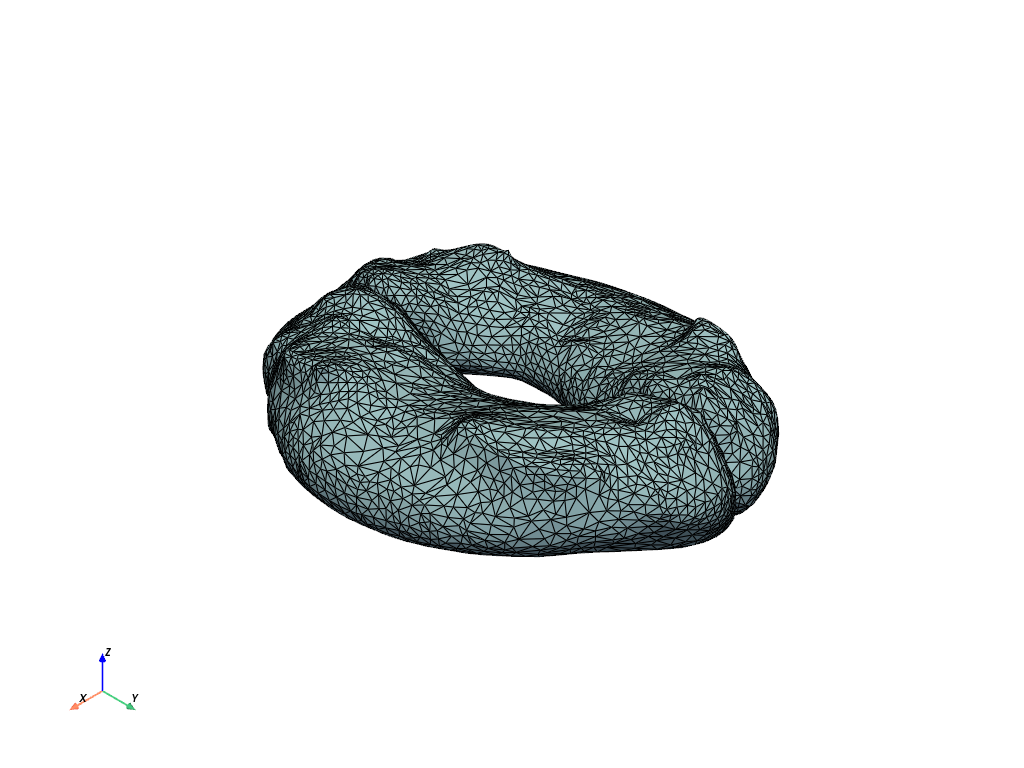

In [20]:
import pyvista as pv

# Load the simplified mesh
simplified_mesh = pv.read('output.ply')

# Visualize the mesh
plotter = pv.Plotter()
plotter.add_mesh(simplified_mesh, color='lightblue', show_edges=True)  # Customize the mesh appearance
plotter.add_axes()  # Optionally, add axes for orientation
plotter.show()  # Show the plot


In [21]:
import pyvista as pv

# Load the meshes
mesh1 = pv.read('/Users/tomkinsm/stomata-air-mattress/Meshes/PLY/mesh_1_2.ply')
mesh2 = pv.read('/Users/tomkinsm/stomata-air-mattress/Meshes/PLY/mesh_1_3.ply')

# Target number of vertices
TARGET_VERTICES = 10000

# Function to decimate or subdivide mesh to match target vertices
def match_vertices(mesh, target_vertices):
    # Decimate the mesh until it reaches the target number of vertices
    while mesh.n_points > target_vertices:
        reduction_factor = target_vertices / mesh.n_points
        mesh = mesh.decimate_pro(reduction_factor)

    # If mesh has too few vertices, use subdivision to increase it
    while mesh.n_points < target_vertices:
        mesh = mesh.subdivide(1)  # Increase vertex count by subdivision
    
    return mesh

# Adjust both meshes to have the same number of vertices
mesh1_adjusted = match_vertices(mesh1, TARGET_VERTICES)
mesh2_adjusted = match_vertices(mesh2, TARGET_VERTICES)

# Print the number of vertices to verify
print(f'Mesh 1 vertices: {mesh1_adjusted.n_points}')
print(f'Mesh 2 vertices: {mesh2_adjusted.n_points}')

# Visualize both meshes to confirm
plotter = pv.Plotter()
plotter.add_mesh(mesh1_adjusted, color='lightblue', show_edges=True)
plotter.add_mesh(mesh2_adjusted, color='orange', show_edges=True)
plotter.add_axes()
plotter.show()


ERROR:root:Dataset is non-manifold and cannot be subdivided.
2025-02-02 15:08:50.907 (4095.055s) [         1260C00]vtkLinearSubdivisionFil:69     ERR| vtkLinearSubdivisionFilter (0x35f1b3f30): Dataset is non-manifold and cannot be subdivided.
ERROR:root:Subdivision failed.
2025-02-02 15:08:50.907 (4095.056s) [         1260C00]vtkInterpolatingSubdivi:90     ERR| vtkLinearSubdivisionFilter (0x35f1b3f30): Subdivision failed.
ERROR:root:Algorithm vtkLinearSubdivisionFilter (0x35f1b3f30) returned failure for request: vtkInformation (0x35f1ae880)
2025-02-02 15:08:50.908 (4095.056s) [         1260C00]       vtkExecutive.cxx:730    ERR| vtkCompositeDataPipeline (0x104346cf0): Algorithm vtkLinearSubdivisionFilter (0x35f1b3f30) returned failure for request: vtkInformation (0x35f1ae880)
  Debug: Off
  Modified Time: 1940820
  Reference Count: 1
  Registered Events: (none)
  Request: REQUEST_DATA
  FROM_OUTPUT_PORT: 0
  ALGORITHM_AFTER_FORWARD: 1
  FORWARD_DIRECTION: 0




NotAllTrianglesError: Input mesh for subdivision must be all triangles.

In [29]:
import pyvista as pv
import numpy as np
from scipy.spatial.transform import Rotation as R

def icp(A, B, max_iterations=100, tolerance=1e-6):
    """Perform Iterative Closest Point (ICP) algorithm to align points A to points B."""
    A = np.array(A)
    B = np.array(B)
    n_points, n_dims = A.shape

    # Initialize transformation
    R_mat = np.eye(n_dims)
    t = np.zeros(n_dims)
    A_aligned = A.copy()

    for _ in range(max_iterations):
        # Find the nearest neighbors
        distances = np.linalg.norm(A_aligned[:, np.newaxis] - B, axis=2)
        indices = np.argmin(distances, axis=1)
        B_matched = B[indices]

        # Compute centroids
        centroid_A = np.mean(A_aligned, axis=0)
        centroid_B = np.mean(B_matched, axis=0)

        # Center the points
        A_centered = A_aligned - centroid_A
        B_centered = B_matched - centroid_B

        # Compute covariance matrix and perform SVD
        H = A_centered.T @ B_centered
        U, _, Vt = np.linalg.svd(H)
        R_new = Vt.T @ U.T

        # Ensure proper rotation (det(R) = 1)
        if np.linalg.det(R_new) < 0:
            Vt[-1, :] *= -1
            R_new = Vt.T @ U.T

        t_new = centroid_B - R_new @ centroid_A

        # Apply transformation
        A_aligned = (R_new @ A_aligned.T).T + t_new

        # Check for convergence
        if np.linalg.norm(R_new - R_mat) < tolerance and np.linalg.norm(t_new - t) < tolerance:
            break

        R_mat = R_new
        t = t_new

    return A_aligned, R_mat, t

# Load PLY meshes
mesh1 = pv.read("/Users/tomkinsm/stomata-air-mattress/Meshes/PLY/mesh_1_2.ply")  # Reference mesh
mesh2 = pv.read("/Users/tomkinsm/stomata-air-mattress/Meshes/PLY/mesh_1_3.ply")  # Mesh to align

# Smooth the meshes
smoothed_mesh1 = mesh1.smooth(n_iter=100)  # Smooth reference mesh
smoothed_mesh2 = mesh2.smooth(n_iter=100)  # Smooth misaligned mesh

# Extract vertices from the smoothed meshes
vertices1 = smoothed_mesh1.points  # Reference vertices
vertices2 = smoothed_mesh2.points  # Vertices to align

# Optionally, apply an initial misalignment (e.g., rotation + translation)
rotation = R.from_euler('z', 30, degrees=True).as_matrix()  # Rotate 30° around Z-axis
translation = np.array([0.5, 0.5, 0])  # Shift along X and Y axes
transformed_vertices = (rotation @ vertices2.T).T + translation  # Apply rotation + translation

# Run ICP to align the misaligned mesh to the reference mesh
aligned_vertices, R_icp, t_icp = icp(transformed_vertices, vertices1)

# Create new meshes for visualization
aligned_mesh = pv.PolyData(aligned_vertices, mesh2.faces)  # Aligned mesh
misaligned_mesh = pv.PolyData(transformed_vertices, mesh2.faces)  # Misaligned mesh

# Average the aligned meshes
average_vertices = (vertices1 + aligned_vertices) / 2  # Average of reference and aligned vertices
average_mesh = pv.PolyData(average_vertices, mesh1.faces)  # Use faces from reference mesh

# Visualization
plotter = pv.Plotter()
plotter.add_mesh(smoothed_mesh1, color="blue", opacity=0.3, label="Smoothed Reference Mesh", style="wireframe")
plotter.add_mesh(misaligned_mesh, color="green", opacity=1.0, label="Smoothed Misaligned Mesh", style="wireframe")
plotter.add_mesh(aligned_mesh, color="red", opacity=1.0, label="Aligned Mesh", style="wireframe")
plotter.add_mesh(average_mesh, color="yellow", opacity=1.0, label="Averaged Mesh", style="wireframe")
plotter.add_legend()
plotter.show()

# Optionally, save the averaged mesh as a new PLY file
average_mesh.save("averaged_mesh.ply")

ValueError: operands could not be broadcast together with shapes (14291,3) (13783,3) 

In [8]:
import pyvista as pv
import numpy as np
from scipy.spatial.transform import Rotation as R
import vtk

def icp(A, B, max_iterations=100, tolerance=1e-6):
    """Perform Iterative Closest Point (ICP) algorithm to align points A to points B."""
    A = np.array(A)
    B = np.array(B)
    n_points, n_dims = A.shape

    # Initialize transformation
    R_mat = np.eye(n_dims)
    t = np.zeros(n_dims)
    A_aligned = A.copy()

    for _ in range(max_iterations):
        # Find the nearest neighbors
        distances = np.linalg.norm(A_aligned[:, np.newaxis] - B, axis=2)
        indices = np.argmin(distances, axis=1)
        B_matched = B[indices]

        # Compute centroids
        centroid_A = np.mean(A_aligned, axis=0)
        centroid_B = np.mean(B_matched, axis=0)

        # Center the points
        A_centered = A_aligned - centroid_A
        B_centered = B_matched - centroid_B

        # Compute covariance matrix and perform SVD
        H = A_centered.T @ B_centered
        U, _, Vt = np.linalg.svd(H)
        R_new = Vt.T @ U.T

        # Ensure proper rotation (det(R) = 1)
        if np.linalg.det(R_new) < 0:
            Vt[-1, :] *= -1
            R_new = Vt.T @ U.T

        t_new = centroid_B - R_new @ centroid_A

        # Apply transformation
        A_aligned = (R_new @ A_aligned.T).T + t_new

        # Check for convergence
        if np.linalg.norm(R_new - R_mat) < tolerance and np.linalg.norm(t_new - t) < tolerance:
            break

        R_mat = R_new
        t = t_new

    return A_aligned, R_mat, t

def sample_points(mesh, num_points):
    """Uniformly sample points from a mesh."""
    mask_points = vtk.vtkMaskPoints()
    mask_points.SetInputData(mesh)
    mask_points.SetOnRatio(int(mesh.n_points / num_points))
    mask_points.RandomModeOn()
    mask_points.Update()
    sampled_mesh = pv.wrap(mask_points.GetOutput())
    return sampled_mesh

# Load PLY meshes
mesh1 = pv.read("/Users/tomkinsm/stomata-air-mattress/Meshes/PLY/mesh_1_2.ply")  # Reference mesh
mesh2 = pv.read("/Users/tomkinsm/stomata-air-mattress/Meshes/PLY/mesh_1_3.ply")  # Mesh to align

# Define the number of vertices to resample to
num_vertices = 10000

# Resample the meshes to have the same number of vertices
resampled_mesh1 = sample_points(mesh1,num_vertices)
resampled_mesh2 = sample_points(mesh2,num_vertices)

# Extract the vertices of the resampled meshes
vertices1 = resampled_mesh1.points
vertices2 = resampled_mesh2.points


# Smooth the meshes (optional)
smoothed_mesh1 = resampled_mesh1.smooth(n_iter=100)
smoothed_mesh2 = resampled_mesh2.smooth(n_iter=100)

# Extract vertices from the smoothed meshes
vertices1 = smoothed_mesh1.points  # Reference vertices
vertices2 = smoothed_mesh2.points  # Vertices to align

# Align the meshes using ICP
aligned_vertices, R_icp, t_icp = icp(vertices2, vertices1)

# Create a point cloud from the aligned vertices
aligned_mesh = pv.PolyData(aligned_vertices)

# Compute the mean shape by averaging corresponding vertices
mean_vertices = (vertices1 + aligned_vertices) / 2
mean_mesh = pv.PolyData(mean_vertices, mesh1.faces)  # Use faces from reference mesh

# Visualization
plotter = pv.Plotter()
plotter.add_mesh(smoothed_mesh1, color="blue", opacity=0.3, label="Reference Mesh", style="wireframe")
plotter.add_mesh(aligned_mesh, color="red", opacity=1.0, label="Aligned Mesh", style="wireframe")
plotter.add_mesh(mean_mesh, color="yellow", opacity=1.0, label="Mean Mesh", style="wireframe")
plotter.add_legend()
plotter.show()

# Save the mean mesh
mean_mesh.save("mean_mesh.ply")

ERROR:root:No data to smooth!
2025-01-31 14:31:31.934 ( 438.891s) [          DF80B9]vtkSmoothPolyDataFilter:318    ERR| vtkSmoothPolyDataFilter (0x108acf110): No data to smooth!
ERROR:root:No data to smooth!
2025-01-31 14:31:31.934 ( 438.891s) [          DF80B9]vtkSmoothPolyDataFilter:318    ERR| vtkSmoothPolyDataFilter (0x3028a77b0): No data to smooth!


ValueError: attempt to get argmin of an empty sequence

In [12]:
import pyvista as pv
import numpy as np
from scipy.spatial.transform import Rotation as R
import vtk

def icp(A, B, max_iterations=100, tolerance=1e-6):
    """Perform Iterative Closest Point (ICP) algorithm to align points A to points B."""
    A = np.array(A)
    B = np.array(B)
    n_points, n_dims = A.shape

    # Initialize transformation
    R_mat = np.eye(n_dims)
    t = np.zeros(n_dims)
    A_aligned = A.copy()

    for _ in range(max_iterations):
        # Find the nearest neighbors
        distances = np.linalg.norm(A_aligned[:, np.newaxis] - B, axis=2)
        if distances.size == 0:
            raise ValueError("Distances array is empty. Check the input data.")
        indices = np.argmin(distances, axis=1)
        B_matched = B[indices]

        # Compute centroids
        centroid_A = np.mean(A_aligned, axis=0)
        centroid_B = np.mean(B_matched, axis=0)

        # Center the points
        A_centered = A_aligned - centroid_A
        B_centered = B_matched - centroid_B

        # Compute covariance matrix and perform SVD
        H = A_centered.T @ B_centered
        U, _, Vt = np.linalg.svd(H)
        R_new = Vt.T @ U.T

        # Ensure proper rotation (det(R) = 1)
        if np.linalg.det(R_new) < 0:
            Vt[-1, :] *= -1
            R_new = Vt.T @ U.T

        t_new = centroid_B - R_new @ centroid_A

        # Apply transformation
        A_aligned = (R_new @ A.T).T + t_new

        # Check for convergence
        if np.linalg.norm(R_new - R_mat) < tolerance and np.linalg.norm(t_new - t) < tolerance:
            break

        R_mat = R_new
        t = t_new

    return A_aligned, R_mat, t

def sample_points(mesh, num_points):
    """Uniformly sample points from a mesh."""
    mask_points = vtk.vtkMaskPoints()
    mask_points.SetInputData(mesh)
    mask_points.SetOnRatio(int(mesh.n_points / num_points))
    mask_points.RandomModeOn()
    mask_points.Update()
    sampled_mesh = pv.wrap(mask_points.GetOutput())
    return sampled_mesh

# Load the PLY meshes
mesh1 = pv.read("/Users/tomkinsm/stomata-air-mattress/Meshes/PLY/mesh_1_2.ply")  # Reference mesh
mesh2 = pv.read("/Users/tomkinsm/stomata-air-mattress/Meshes/PLY/mesh_1_3.ply")  # Mesh to align

# Define the number of vertices to resample to
num_vertices = 10000

# Resample the meshes to have the same number of vertices
resampled_mesh1 = sample_points(mesh1, num_vertices)
resampled_mesh2 = sample_points(mesh2, num_vertices)

# Extract the vertices of the resampled meshes
vertices1 = resampled_mesh1.points
vertices2 = resampled_mesh2.points

# Ensure that the vertices arrays are not empty
if vertices1.size == 0 or vertices2.size == 0:
    raise ValueError("One of the vertices arrays is empty. Check the sampling process.")

# Run ICP to align the resampled meshes
aligned_vertices, R_icp, t_icp = icp(vertices2, vertices1)

# Create PolyData objects for visualization
reference_mesh = pv.PolyData(vertices1, resampled_mesh1.faces)
misaligned_mesh = pv.PolyData(vertices2, resampled_mesh2.faces)
aligned_mesh = pv.PolyData(aligned_vertices, resampled_mesh2.faces)

# Visualization
plotter = pv.Plotter()
plotter.add_mesh(reference_mesh, color="blue", opacity=0.5, label="Reference Mesh")
plotter.add_mesh(misaligned_mesh, color="green", opacity=0.5, label="Misaligned Mesh")
plotter.add_mesh(aligned_mesh, color="red", opacity=0.5, label="Aligned Mesh")
plotter.add_legend()
plotter.show()

Widget(value='<iframe src="http://localhost:60253/index.html?ui=P_0x332552de0_2&reconnect=auto" class="pyvista…

In [18]:
import pyvista as pv
import numpy as np
from scipy.spatial.transform import Rotation as R
import vtk
import open3d as o3d

def icp(A, B, max_iterations=100, tolerance=1e-6):
    """Perform Iterative Closest Point (ICP) algorithm to align points A to points B."""
    A = np.array(A)
    B = np.array(B)
    n_points, n_dims = A.shape

    # Initialize transformation
    R_mat = np.eye(n_dims)
    t = np.zeros(n_dims)
    A_aligned = A.copy()

    for _ in range(max_iterations):
        # Find the nearest neighbors
        distances = np.linalg.norm(A_aligned[:, np.newaxis] - B, axis=2)
        if distances.size == 0:
            raise ValueError("Distances array is empty. Check the input data.")
        indices = np.argmin(distances, axis=1)
        B_matched = B[indices]

        # Compute centroids
        centroid_A = np.mean(A_aligned, axis=0)
        centroid_B = np.mean(B_matched, axis=0)

        # Center the points
        A_centered = A_aligned - centroid_A
        B_centered = B_matched - centroid_B

        # Compute covariance matrix and perform SVD
        H = A_centered.T @ B_centered
        U, _, Vt = np.linalg.svd(H)
        R_new = Vt.T @ U.T

        # Ensure proper rotation (det(R) = 1)
        if np.linalg.det(R_new) < 0:
            Vt[-1, :] *= -1
            R_new = Vt.T @ U.T

        t_new = centroid_B - R_new @ centroid_A

        # Apply transformation
        A_aligned = (R_new @ A.T).T + t_new

        # Check for convergence
        if np.linalg.norm(R_new - R_mat) < tolerance and np.linalg.norm(t_new - t) < tolerance:
            break

        R_mat = R_new
        t = t_new

    return A_aligned, R_mat, t

def sample_points(mesh, num_points):
    """Uniformly sample points from a mesh."""
    mask_points = vtk.vtkMaskPoints()
    mask_points.SetInputData(mesh)
    mask_points.SetOnRatio(int(mesh.n_points / num_points))
    mask_points.RandomModeOn()
    mask_points.Update()
    sampled_mesh = pv.wrap(mask_points.GetOutput())
    return sampled_mesh

def convert_to_open3d(pv_mesh):
    """Convert a PyVista mesh to an Open3D point cloud."""
    points = pv_mesh.points
    o3d_pcd = o3d.geometry.PointCloud()
    o3d_pcd.points = o3d.utility.Vector3dVector(points)
    return o3d_pcd

def poisson_reconstruction(o3d_pcd):
    """Perform Poisson surface reconstruction on an Open3D point cloud."""
    o3d_pcd.estimate_normals()
    mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(o3d_pcd, depth=9)
    return mesh

# Load the PLY meshes
mesh1 = pv.read("/Users/tomkinsm/stomata-air-mattress/Meshes/PLY/mesh_1_2.ply")  # Reference mesh
mesh2 = pv.read("/Users/tomkinsm/stomata-air-mattress/Meshes/PLY/mesh_1_3.ply")  # Mesh to align


# Define the number of vertices to resample to
num_vertices = 1000

# Resample the meshes to have the same number of vertices
resampled_mesh1 = sample_points(mesh1, num_vertices)
resampled_mesh2 = sample_points(mesh2, num_vertices)

# Extract the vertices of the resampled meshes
vertices1 = resampled_mesh1.points
vertices2 = resampled_mesh2.points

# Ensure that the vertices arrays are not empty
if vertices1.size == 0 or vertices2.size == 0:
    raise ValueError("One of the vertices arrays is empty. Check the sampling process.")

# Run ICP to align the resampled meshes
aligned_vertices, R_icp, t_icp = icp(vertices2, vertices1)

# Convert PyVista point clouds to Open3D point clouds
o3d_pcd1 = convert_to_open3d(resampled_mesh1)
o3d_pcd2 = convert_to_open3d(resampled_mesh2)
o3d_pcd_aligned = convert_to_open3d(pv.PolyData(aligned_vertices))

# Perform Poisson surface reconstruction
o3d_mesh1 = poisson_reconstruction(o3d_pcd1)
o3d_mesh2 = poisson_reconstruction(o3d_pcd2)
o3d_mesh_aligned = poisson_reconstruction(o3d_pcd_aligned)

# Convert Open3D meshes back to PyVista meshes
pv_mesh1 = pv.wrap(o3d_mesh1)
pv_mesh2 = pv.wrap(o3d_mesh2)
pv_mesh_aligned = pv.wrap(o3d_mesh_aligned)

# Visualization
plotter = pv.Plotter()
plotter.add_mesh(reference_mesh, color="blue", opacity=0.5, label="Reference Mesh")
plotter.add_mesh(misaligned_mesh, color="green", opacity=0.5, label="Misaligned Mesh")
plotter.add_mesh(aligned_mesh, color="red", opacity=0.5, label="Aligned Mesh")
plotter.add_legend()
plotter.show()

NotImplementedError: Unable to wrap (<class 'open3d.cpu.pybind.geometry.TriangleMesh'>) into a pyvista type.

In [19]:
import pyvista as pv
import numpy as np
from scipy.spatial.transform import Rotation as R
import vtk
import open3d as o3d

def icp(A, B, max_iterations=100, tolerance=1e-6):
    """Perform Iterative Closest Point (ICP) algorithm to align points A to points B."""
    A = np.array(A)
    B = np.array(B)
    n_points, n_dims = A.shape

    # Initialize transformation
    R_mat = np.eye(n_dims)
    t = np.zeros(n_dims)
    A_aligned = A.copy()

    for _ in range(max_iterations):
        # Find the nearest neighbors
        distances = np.linalg.norm(A_aligned[:, np.newaxis] - B, axis=2)
        if distances.size == 0:
            raise ValueError("Distances array is empty. Check the input data.")
        indices = np.argmin(distances, axis=1)
        B_matched = B[indices]

        # Compute centroids
        centroid_A = np.mean(A_aligned, axis=0)
        centroid_B = np.mean(B_matched, axis=0)

        # Center the points
        A_centered = A_aligned - centroid_A
        B_centered = B_matched - centroid_B

        # Compute covariance matrix and perform SVD
        H = A_centered.T @ B_centered
        U, _, Vt = np.linalg.svd(H)
        R_new = Vt.T @ U.T

        # Ensure proper rotation (det(R) = 1)
        if np.linalg.det(R_new) < 0:
            Vt[-1, :] *= -1
            R_new = Vt.T @ U.T

        t_new = centroid_B - R_new @ centroid_A

        # Apply transformation
        A_aligned = (R_new @ A.T).T + t_new

        # Check for convergence
        if np.linalg.norm(R_new - R_mat) < tolerance and np.linalg.norm(t_new - t) < tolerance:
            break

        R_mat = R_new
        t = t_new

    return A_aligned, R_mat, t

def sample_points(mesh, num_points):
    """Uniformly sample points from a mesh."""
    mask_points = vtk.vtkMaskPoints()
    mask_points.SetInputData(mesh)
    mask_points.SetOnRatio(int(mesh.n_points / num_points))
    mask_points.RandomModeOn()
    mask_points.Update()
    sampled_mesh = pv.wrap(mask_points.GetOutput())
    return sampled_mesh

def convert_to_open3d(pv_mesh):
    """Convert a PyVista mesh to an Open3D point cloud."""
    points = pv_mesh.points
    o3d_pcd = o3d.geometry.PointCloud()
    o3d_pcd.points = o3d.utility.Vector3dVector(points)
    return o3d_pcd

def poisson_reconstruction(o3d_pcd):
    """Perform Poisson surface reconstruction on an Open3D point cloud."""
    o3d_pcd.estimate_normals()
    mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(o3d_pcd, depth=9)
    return mesh

def convert_open3d_to_pyvista(o3d_mesh):
    """Convert an Open3D mesh to a PyVista mesh."""
    vertices = np.asarray(o3d_mesh.vertices)
    faces = np.asarray(o3d_mesh.triangles)
    faces = np.hstack([np.full((faces.shape[0], 1), 3), faces]).flatten()
    pv_mesh = pv.PolyData(vertices, faces)
    return pv_mesh

# Load the PLY meshes
mesh1 = pv.read("/Users/tomkinsm/stomata-air-mattress/Meshes/PLY/mesh_1_2.ply")  # Reference mesh
mesh2 = pv.read("/Users/tomkinsm/stomata-air-mattress/Meshes/PLY/mesh_1_3.ply")  # Mesh to align


# Define the number of vertices to resample to
num_vertices = 1000

# Resample the meshes to have the same number of vertices
resampled_mesh1 = sample_points(mesh1, num_vertices)
resampled_mesh2 = sample_points(mesh2, num_vertices)

# Extract the vertices of the resampled meshes
vertices1 = resampled_mesh1.points
vertices2 = resampled_mesh2.points

# Ensure that the vertices arrays are not empty
if vertices1.size == 0 or vertices2.size == 0:
    raise ValueError("One of the vertices arrays is empty. Check the sampling process.")

# Run ICP to align the resampled meshes
aligned_vertices, R_icp, t_icp = icp(vertices2, vertices1)

# Convert PyVista point clouds to Open3D point clouds
o3d_pcd1 = convert_to_open3d(resampled_mesh1)
o3d_pcd2 = convert_to_open3d(resampled_mesh2)
o3d_pcd_aligned = convert_to_open3d(pv.PolyData(aligned_vertices))

# Perform Poisson surface reconstruction
o3d_mesh1 = poisson_reconstruction(o3d_pcd1)
o3d_mesh2 = poisson_reconstruction(o3d_pcd2)
o3d_mesh_aligned = poisson_reconstruction(o3d_pcd_aligned)

# Convert Open3D meshes back to PyVista meshes
pv_mesh1 = convert_open3d_to_pyvista(o3d_mesh1)
pv_mesh2 = convert_open3d_to_pyvista(o3d_mesh2)
pv_mesh_aligned = convert_open3d_to_pyvista(o3d_mesh_aligned)

# Visualization
plotter = pv.Plotter()
plotter.add_mesh(pv_mesh1, color="blue", opacity=0.5, label="Reference Mesh")
plotter.add_mesh(pv_mesh2, color="green", opacity=0.5, label="Misaligned Mesh")
plotter.add_mesh(pv_mesh_aligned, color="red", opacity=0.5, label="Aligned Mesh")
plotter.add_legend()
plotter.show()

Widget(value='<iframe src="http://localhost:60253/index.html?ui=P_0x361a133e0_5&reconnect=auto" class="pyvista…

In [1]:
import pyvista as pv
import pymeshlab as ml
import open3d as o3d
import numpy as np
import glob

# Load all OBJ meshes from a folder
mesh_files = glob.glob("/Users/tomkinsm/stomata-air-mattress/Meshes/OBJ/*.obj")  # Adjust path

# Step 1: Load and Preprocess Meshes
def load_and_clean_mesh(file):
    mesh = pv.read(file)
    # Ensure it's a closed surface
    mesh = mesh.extract_surface().clean()
    return mesh

# Load all meshes
meshes = [load_and_clean_mesh(f) for f in mesh_files]

# Step 2: Align all meshes to a common reference using ICP
def align_mesh(source_mesh, target_mesh):
    source = o3d.geometry.PointCloud()
    target = o3d.geometry.PointCloud()
    source.points = o3d.utility.Vector3dVector(source_mesh.points)
    target.points = o3d.utility.Vector3dVector(target_mesh.points)

    # ICP Alignment
    threshold = 0.02
    icp_result = o3d.pipelines.registration.registration_icp(
        source, target, threshold, np.eye(4),
        o3d.pipelines.registration.TransformationEstimationPointToPoint()
    )
    # Apply transformation
    aligned_source = source.transform(icp_result.transformation)
    return pv.PolyData(np.asarray(aligned_source.points), target_mesh.faces)

# Use the first mesh as reference and align all others
reference_mesh = meshes[0]
aligned_meshes = [reference_mesh] + [align_mesh(m, reference_mesh) for m in meshes[1:]]

# Step 3: Resample to ensure same number of vertices
target_vertex_count = 5000  # Choose a suitable number
def resample_mesh(mesh, filename="temp.ply"):
    """Resample a PyVista mesh using PyMeshLab to match a target number of vertices."""
    
    # Save the PyVista mesh as a temporary PLY file
    temp_input = filename
    temp_output = "resampled_" + filename
    mesh.save(temp_input)
    
    # Load into PyMeshLab
    ms = ml.MeshSet()
    ms.load_new_mesh(temp_input)

    # Apply resampling to match the target vertex count
    ms.apply_filter('meshing_decimation_quadric_edge_collapse', targetfacenum=target_vertex_count)

    # Save the resampled mesh
    ms.save_current_mesh(temp_output)

    # Load back into PyVista
    return pv.read(temp_output)

# Apply resampling to all aligned meshes
resampled_meshes = [resample_mesh(m, f"mesh_{i}.obj") for i, m in enumerate(aligned_meshes)]

# Step 4: Compute the median shape
vertex_stack = np.array([m.points for m in resampled_meshes])  # Shape: (18, num_vertices, 3)
median_vertices = np.median(vertex_stack, axis=0)

# Step 5: Construct the median mesh
median_mesh = pv.PolyData(median_vertices, reference_mesh.faces)

# Step 6: Post-process the median mesh (smoothing)
def smooth_mesh(mesh, iterations=10):
    ms = ml.MeshSet()
    ms.load_new_mesh_from_array(mesh.points, mesh.faces.reshape(-1, 4)[:, 1:])
    ms.apply_filter('apply_coord_laplacian_smoothing', stepsmoothnum=iterations)
    return pv.PolyData(ms.current_mesh().vertex_matrix(), ms.current_mesh().face_matrix())

smoothed_median_mesh = smooth_mesh(median_mesh)

# Step 7: Save and visualize
smoothed_median_mesh.save("median_mesh.obj")

# Visualization
plotter = pv.Plotter()
plotter.add_mesh(reference_mesh, color="blue", opacity=0.3, label="Reference Mesh", style="wireframe")
plotter.add_mesh(smoothed_median_mesh, color="red", opacity=1.0, label="Median Mesh", style="wireframe")
plotter.add_legend()
plotter.show()


: 